# ch273 — Descriptive Statistics

*(Builds on ch271 — Data and Measurement; uses expected value formalism from ch249 — Expected Value)*

## 1. Purpose

Descriptive statistics summarize a dataset's essential character with a small set of numbers. The goal is not compression for its own sake — it is that human perception cannot process 10,000 numbers simultaneously, but it can process four.

Every summary statistic discards information. The question is which information to discard and what guarantee the retained numbers provide.

---

## 2. Measures of Central Tendency

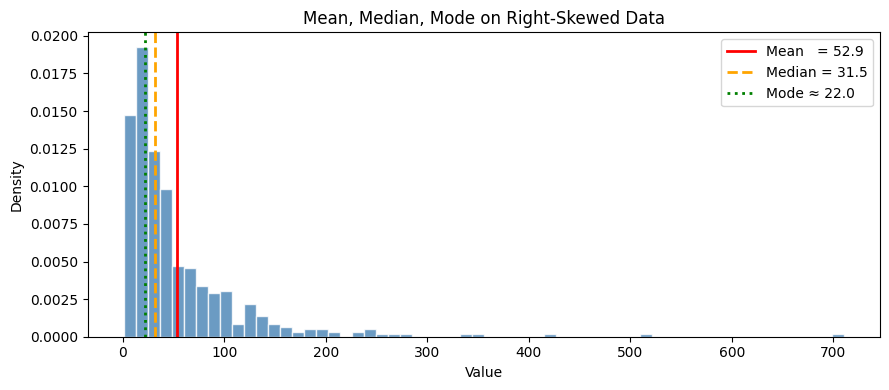

For right-skewed data: mode < median < mean.
The mean is pulled right by extreme values; the median is not.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Right-skewed data (e.g., income)
data = rng.lognormal(mean=3.5, sigma=1.0, size=500)

def mean(x):   return x.sum() / len(x)
def median(x): return np.sort(x)[len(x) // 2] if len(x) % 2 == 1 else \
                      (np.sort(x)[len(x)//2 - 1] + np.sort(x)[len(x)//2]) / 2
def mode_approx(x, bins=50):
    """Mode of a continuous variable via histogram peak."""
    counts, edges = np.histogram(x, bins=bins)
    peak_bin = np.argmax(counts)
    return (edges[peak_bin] + edges[peak_bin + 1]) / 2

m   = mean(data)
med = median(data)
mod = mode_approx(data)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
ax.axvline(m,   color='red',    lw=2, ls='-',  label=f'Mean   = {m:.1f}')
ax.axvline(med, color='orange', lw=2, ls='--', label=f'Median = {med:.1f}')
ax.axvline(mod, color='green',  lw=2, ls=':',  label=f'Mode ≈ {mod:.1f}')
ax.set_xlabel('Value'); ax.set_ylabel('Density')
ax.set_title('Mean, Median, Mode on Right-Skewed Data')
ax.legend()
plt.tight_layout()
plt.show()

print("For right-skewed data: mode < median < mean.")
print("The mean is pulled right by extreme values; the median is not.")

### The Mean as an Optimization

The mean minimizes the sum of squared deviations:
$$\bar{x} = \arg\min_c \sum_{i=1}^n (x_i - c)^2$$

The median minimizes the sum of absolute deviations:
$$\text{median} = \arg\min_c \sum_{i=1}^n |x_i - c|$$

This is why the median is robust to outliers: the absolute loss does not penalize large deviations as heavily as the squared loss. *(Gradient descent perspective introduced in ch213 — Gradient Descent)*

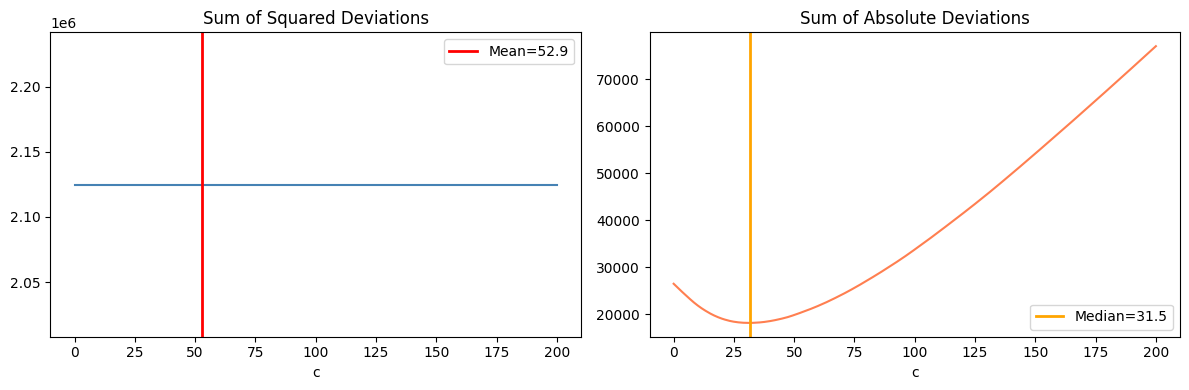

In [2]:
# Verify mean/median as optimizers
c_vals = np.linspace(0, 200, 500)
sq_loss  = [(data - c).var() * len(data) for c in c_vals]   # sum of squares
abs_loss = [np.abs(data - c).sum() for c in c_vals]          # sum of absolutes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(c_vals, sq_loss, color='steelblue')
ax1.axvline(m, color='red', lw=2, label=f'Mean={m:.1f}')
ax1.set_title('Sum of Squared Deviations'); ax1.set_xlabel('c'); ax1.legend()

ax2.plot(c_vals, abs_loss, color='coral')
ax2.axvline(med, color='orange', lw=2, label=f'Median={med:.1f}')
ax2.set_title('Sum of Absolute Deviations'); ax2.set_xlabel('c'); ax2.legend()

plt.tight_layout()
plt.show()

## 3. Measures of Spread

| Statistic | Formula | Properties |
|---|---|---|
| Range | max − min | Simple; highly sensitive to outliers |
| Variance | $\frac{1}{n-1}\sum(x_i - \bar{x})^2$ | Squared units; sensitive to outliers |
| Std deviation | $\sqrt{\text{variance}}$ | Same units as data |
| IQR | Q3 − Q1 | Robust; covers central 50% |
| MAD | median|x_i − median| | Most robust; hard to use analytically |

Why divide by n−1 (Bessel's correction) in sample variance? Because the sample mean is computed from the same data, consuming one degree of freedom. Dividing by n gives a biased estimator that systematically underestimates the population variance.

In [3]:
def sample_variance(x):
    """Unbiased sample variance (Bessel's correction: n-1)."""
    n = len(x)
    mu = x.mean()
    return np.sum((x - mu)**2) / (n - 1)

def iqr(x):
    q1, q3 = np.percentile(x, [25, 75])
    return q3 - q1

def mad(x):
    return np.median(np.abs(x - np.median(x)))

# Compare on clean vs contaminated data
clean = rng.normal(50, 10, 200)
dirty = np.concatenate([clean, [500, 600, 700]])  # 3 outliers

print("Statistic         Clean     Contaminated")
print("-" * 45)
for name, fn in [
    ('Std deviation',   lambda x: np.sqrt(sample_variance(x))),
    ('IQR',             iqr),
    ('MAD',             mad),
    ('Range',           lambda x: x.max() - x.min()),
]:
    print(f"{name:<20} {fn(clean):>6.2f}    {fn(dirty):>12.2f}")

Statistic         Clean     Contaminated
---------------------------------------------
Std deviation          9.56           67.93
IQR                   13.26           14.01
MAD                    6.81            7.07
Range                 48.14          674.22


## 4. Shape: Skewness and Kurtosis

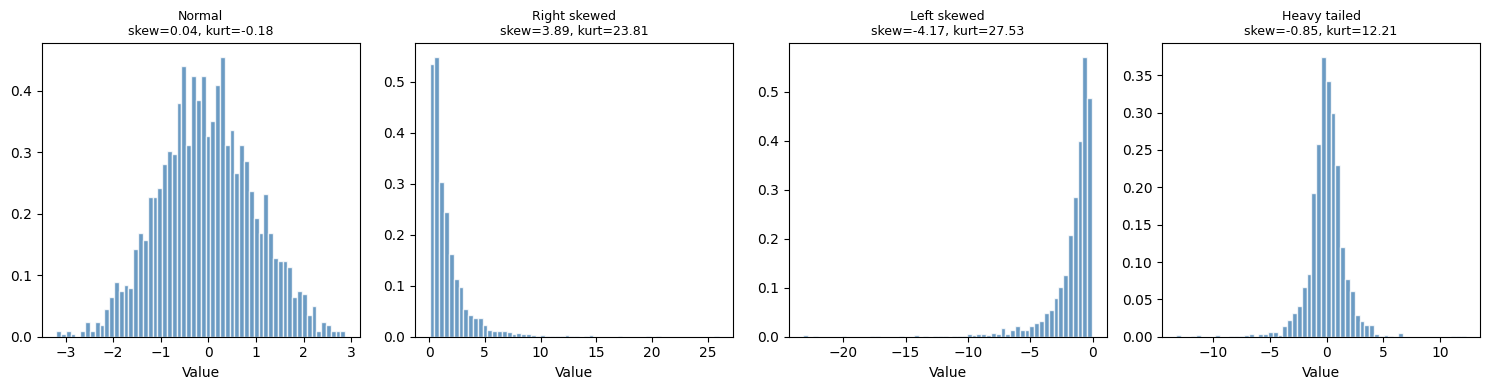

In [4]:
def skewness(x):
    """Fisher's moment coefficient of skewness."""
    n  = len(x)
    mu = x.mean()
    s  = x.std(ddof=1)
    return (n / ((n-1)*(n-2))) * np.sum(((x - mu)/s)**3)

def kurtosis(x):
    """Excess kurtosis (0 for normal distribution)."""
    n  = len(x)
    mu = x.mean()
    s  = x.std(ddof=1)
    return np.mean(((x - mu)/s)**4) - 3

datasets = {
    'Normal':      rng.normal(0, 1, 2000),
    'Right skewed': rng.lognormal(0, 1, 2000),
    'Left skewed':  -rng.lognormal(0, 1, 2000),
    'Heavy tailed': rng.standard_t(df=3, size=2000),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (name, d) in zip(axes, datasets.items()):
    ax.hist(d, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.set_title(f'{name}\nskew={skewness(d):.2f}, kurt={kurtosis(d):.2f}', fontsize=9)
    ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

## 5. The Five-Number Summary and Box Plots

Group A: min=24.8 Q1=44.8 med=50.8 Q3=56.4 max=70.2
Group B: min=16.4 Q1=43.5 med=55.1 Q3=65.7 max=91.7
Group C: min=6.3 Q1=31.5 med=43.2 Q3=59.4 max=148.7


C:\Users\user\AppData\Local\Temp\ipykernel_19568\2790249566.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(list(groups.values()), labels=list(groups.keys()),


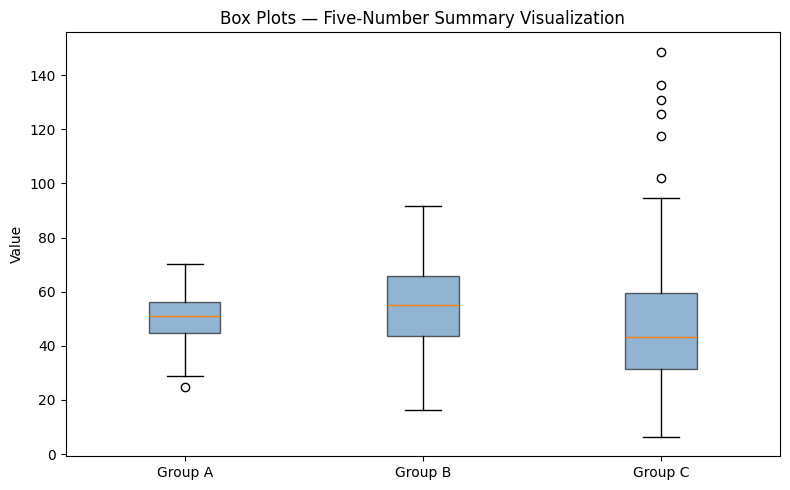

In [5]:
def five_number_summary(x):
    return {
        'min':    x.min(),
        'Q1':     np.percentile(x, 25),
        'median': np.median(x),
        'Q3':     np.percentile(x, 75),
        'max':    x.max(),
    }

groups = {
    'Group A': rng.normal(50, 8, 200),
    'Group B': rng.normal(55, 15, 200),
    'Group C': rng.lognormal(3.8, 0.5, 200),
}

for name, d in groups.items():
    s = five_number_summary(d)
    print(f"{name}: min={s['min']:.1f} Q1={s['Q1']:.1f} "
          f"med={s['median']:.1f} Q3={s['Q3']:.1f} max={s['max']:.1f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(groups.values()), labels=list(groups.keys()),
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Box Plots — Five-Number Summary Visualization')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

## 6. Covariance and Correlation (Preview)

Descriptive statistics for a single variable are insufficient for data with multiple columns. The relationship between variables is captured by covariance:

$$\text{Cov}(X, Y) = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

This will be developed in full in **ch280 — Correlation**. For now, the key point: covariance is a measure of joint spread that generalizes the univariate variance.

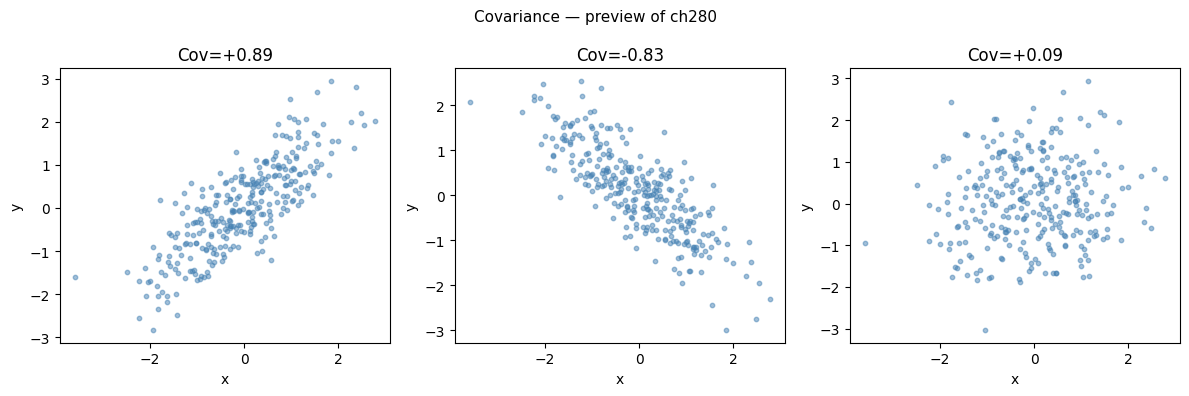

In [6]:
x = rng.normal(0, 1, 300)
y_pos = 0.8 * x + rng.normal(0, 0.6, 300)  # positive covariance
y_neg = -0.8 * x + rng.normal(0, 0.6, 300) # negative covariance
y_zero = rng.normal(0, 1, 300)              # near-zero covariance

def sample_covariance(a, b):
    n = len(a)
    return np.sum((a - a.mean()) * (b - b.mean())) / (n - 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (y, label) in zip(axes, [
    (y_pos,  f'Cov={sample_covariance(x,y_pos):+.2f}'),
    (y_neg,  f'Cov={sample_covariance(x,y_neg):+.2f}'),
    (y_zero, f'Cov={sample_covariance(x,y_zero):+.2f}'),
]):
    ax.scatter(x, y, s=10, alpha=0.5, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Covariance — preview of ch280', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Summary

| Statistic | Sensitive to outliers? | Appropriate scale |
|---|---|---|
| Mean | Yes | Interval, ratio |
| Median | No | Ordinal and above |
| Std deviation | Yes | Interval, ratio |
| IQR | No | Ordinal and above |
| Skewness | Moderate | Continuous |
| Kurtosis | Yes (fourth moment) | Continuous |

## 8. What Comes Next

Numbers alone are insufficient. **ch274 — Visualization of Data** shows how to display distributions, relationships, and comparisons effectively — and why certain charts are actively misleading.

The covariance matrix built here will power **ch280 — Correlation** and **ch281 — Regression**, and will reappear as the matrix being diagonalized in **ch292 — Dimensionality Reduction** (PCA).